# CROCUS Resampled Ozone Study

Ozone and NO₂ from a CROCUS **AQT** air-quality sensor, paired with wind and
temperature from the co-located **WXT** weather transmitter, using the static
5-minute sage-resampled archive (`crocus_store.build_site` output).

A rooftop/urban analogue of the Cook County AQS and NEIU QuantAQ ozone studies,
reusing the same wind-rose and heatmap machinery so all three are comparable.
Because AQT and WXT sit on the same node, there is **no wind displacement**
between pollutant and wind.

**Differences from the NEIU notebook**
- Data are NetCDF with a `statistic` dimension (`mean`/`count`/`std`); we use
  `mean` for values and `count` for QC.
- Times are **UTC**; we convert to America/Chicago so diurnal plots line up.
- Wind is **m/s** (converted to knots for rose bins that match the other
  notebooks); temperature is **°C**.
- No solar/UV radiation. The event-panel bottom row instead overplots WXT and
  AQT temperature as a cross-instrument QA/QC check (WXT is the official temp).
- `SITE` selects the node; site metadata (coordinates, deployment dates) comes
  from `crocus_sites`.


## Imports

In [43]:
import datetime as dt
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytz
import xarray as xr
from IPython.display import display

import crocus_sites

import sys
sys.path.insert(0, "../air_quality")
from plot_utils import plot_hourly_heatmap, nighttime_boxes

from crocus_sites import ATMOS, NEIU, CCICS

## Study configuration

`SITE` selects the CROCUS node (must have **both** AQT and WXT resampled files;
WXT resampling is still in progress for some sites). `YEAR` selects the season.


In [44]:
SITE = "CCICS"     # CROCUS site abbreviation (needs both *_aqt_5min.nc and *_wxt_5min.nc)
YEAR = 2025

# Instrument identity for figure labels. The archive records only the class
# (instrument="aqt"/"wxt"), not the model, so models are named here.
# The NEIU node (VSN W08D) carries a Vaisala AQT530 (air quality) and a
# Vaisala WXT536 (weather transmitter).
# TODO(crocus_store): record instrument make/model/serial in archive attrs.

DATA_DIR = Path("data/sage_resampled")
AQT_PATH = DATA_DIR / f"{SITE}_aqt_5min.nc"
WXT_PATH = DATA_DIR / f"{SITE}_wxt_5min.nc"

FIGURE_DIR = Path("figures") / "resampled" / SITE.lower()
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CHICAGO_TIME = pytz.timezone("America/Chicago")

# Resolve site metadata (coordinates, deployment dates) from crocus_sites.
SITE_META = {s.abbr: s for s in crocus_sites.ALL_SITES}[SITE]
SITE_LAT, SITE_LON = SITE_META.lat, SITE_META.lon
SITE_FULL_NAME = SITE_META.full_name

# Guard: both files must exist. WXT is missing for AQT-only sites (resampling
# in progress); fail clearly rather than deep in a loader.
for _path, _kind in [(AQT_PATH, "AQT"), (WXT_PATH, "WXT")]:
    if not _path.exists():
        raise FileNotFoundError(
            f"{_kind} file not found for {SITE}: {_path}\n"
            f"(WXT resampling may still be in progress for this site.)"
        )

AQT_INSTRUMENT = "Vaisala AQT530"
WXT_INSTRUMENT = "Vaisala WXT536"
AQT_VSN = SITE_META.vsn        # W08D, from crocus_sites

OZONE_COLOR = "#5B9BD5"
NO2_COLOR = "#A0522D"

# Unit conversions to match the other notebooks / rose bins.
MS_TO_KNOTS = 1.943844        # m/s -> knots
# Gases are ppb natively; temperature is degC natively (kept as-is).

# Per-bin QC: a healthy 5-min bin has many raw samples. Drop near-empty bins.
MIN_SAMPLES = 2


## Loaders

Open each NetCDF, take the `mean` statistic, convert UTC→local, apply light
QC via the `count` statistic, and restrict to `YEAR`. Wind is already stored
with the standard meteorological u/v convention (see the WXT
`wind_convention` attribute), so `wind_dir` is direction-**from** in degrees;
no sign fix is needed. We convert wind speed m/s→knots for the rose bins.


In [45]:
def _mean_frame(ds, variables, min_samples):
    """Extract mean values + counts for `variables`, UTC->local, QC-filtered.

    Returns a DataFrame indexed by local (naive) time, one column per variable,
    with bins having fewer than `min_samples` raw samples set to NaN.
    """
    mean = ds[variables].sel(statistic="mean").to_dataframe()[variables]
    count = ds[variables].sel(statistic="count").to_dataframe()[variables]

    # UTC (tz-naive in file) -> America/Chicago wall-clock (tz-naive).
    idx_utc = mean.index.tz_localize("UTC")
    local = idx_utc.tz_convert(CHICAGO_TIME).tz_localize(None)
    mean.index = local
    count.index = local

    mean = mean.mask(count < min_samples)
    return mean

def load_aqt(path, min_samples=MIN_SAMPLES):
    """AQT gases (ppb) + temperature (degC), mean statistic, local time.

    NOTE: the archive labels o3/no2 as 'ppb' but the values are actually ppm
    (a known AQT gas-channel mislabel). We convert ppm -> ppb here so this
    notebook's ppb bins/labels are correct and it matches the QuantAQ notebook.
    """
    ds = xr.open_dataset(path)
    frame = _mean_frame(ds, ["o3", "no2", "temp"], min_samples)

    ds.close()
    frame["o3"] = frame["o3"] * 1000.0     # ppm (mislabeled) -> ppb
    frame["no2"] = frame["no2"] * 1000.0
    frame["o3"] = frame["o3"].clip(lower=0)
    frame["no2"] = frame["no2"].clip(lower=0)
    
    return frame.rename(columns={"temp": "temp_aqt"})

def load_wxt(path, min_samples=MIN_SAMPLES):
    """WXT wind (kn, from-direction) + temperature (degC), mean, local time.

    The archive's stored wind_dir is unpopulated (or absent) by design -- a
    mean direction has no honest std/count, so the resampling keeps only the
    u/v components. We reconstruct from the u/v means: for standard
    meteorological components, the from-direction is atan2(-u, -v) in [0, 360).
    Handles wind_u/wind_v naming (all current files).
    """
    ds = xr.open_dataset(path)
    frame = _mean_frame(ds, ["wind_speed", "wind_u", "wind_v", "temp"], min_samples)
    ds.close()

    frame["wspd"] = frame["wind_speed"] * MS_TO_KNOTS
    frame["wdir"] = (
        np.degrees(np.arctan2(-frame["wind_u"], -frame["wind_v"])) % 360
    )
    frame = frame.rename(columns={"temp": "temp_wxt"})
    return frame[["wspd", "wdir", "temp_wxt"]]

## Load and pair

Inner-join AQT and WXT on the shared 5-min local-time index, then restrict to
`YEAR`. An `ozone_season` view (April–September) matches the other notebooks.
A separate **hourly** ozone/NO₂ series feeds the calendar heatmaps.


In [46]:
aqt = load_aqt(AQT_PATH)
wxt = load_wxt(WXT_PATH)

print(f"AQT rows: {len(aqt):,}  ({aqt.index.min()} .. {aqt.index.max()})")
print(f"WXT rows: {len(wxt):,}  ({wxt.index.min()} .. {wxt.index.max()})")

paired = aqt.join(wxt, how="inner").dropna(subset=["wdir"])
paired = paired[paired.index.year == YEAR].copy()

OZONE_SEASON_MONTHS = range(4, 10)
ozone_season = paired[paired.index.month.isin(OZONE_SEASON_MONTHS)].copy()

# Hourly gas series for the calendar heatmaps (single-pollutant, no wind).
gas_hourly = (
    aqt[aqt.index.year == YEAR][["o3", "no2"]].resample("1h").mean().dropna(how="all")
)

print(f"\nPaired 5-min rows ({YEAR}): {len(paired):,}")
print(f"Paired ozone-season rows: {len(ozone_season):,}")
print(f"Hourly gas rows: {len(gas_hourly):,}")
if len(paired):
    print(f"  O3  ppb: {paired['o3'].min():.1f} .. {paired['o3'].max():.1f}")
    print(f"  NO2 ppb: {paired['no2'].min():.1f} .. {paired['no2'].max():.1f}")
    print(f"  wind kn: {paired['wspd'].min():.1f} .. {paired['wspd'].max():.1f}")
    print(f"  temp C:  {paired['temp_wxt'].min():.1f} .. {paired['temp_wxt'].max():.1f}")


AQT rows: 65,864  (2024-09-25 09:30:00 .. 2025-12-07 17:55:00)
WXT rows: 71,288  (2024-09-25 09:30:00 .. 2025-12-07 17:55:00)

Paired 5-min rows (2025): 46,153
Paired ozone-season rows: 19,149
Hourly gas rows: 3,968
  O3  ppb: 0.0 .. 363.2
  NO2 ppb: 1.1 .. 5096.2
  wind kn: 0.3 .. 31.1
  temp C:  -22.2 .. 33.5


### Coverage check

Deployment start (from `crocus_sites`) and monthly paired-hour counts, so pre-deployment absence isn't mistaken for a data gap.

In [47]:
print(f"{SITE} AQT deployed: {SITE_META.deployment_start('aqt')}")
print(f"{SITE} WXT deployed: {SITE_META.deployment_start('wxt')}\n")

monthly = (paired.groupby(paired.index.month).size()
           .reindex(range(1, 13), fill_value=0))
display(pd.DataFrame({"month": range(1, 13), "paired_5min_rows": monthly.to_numpy()}))


CCICS AQT deployed: 2024-08-27
CCICS WXT deployed: 2024-08-27



,month,paired_5min_rows
0,1,7040
1,2,4545
2,3,8561
3,4,2015
4,5,4029
5,6,1392
6,7,3165
7,8,5223
8,9,3325
9,10,0


Saved figures/resampled/ccics/ccics_ozone_timeseries_2025.png


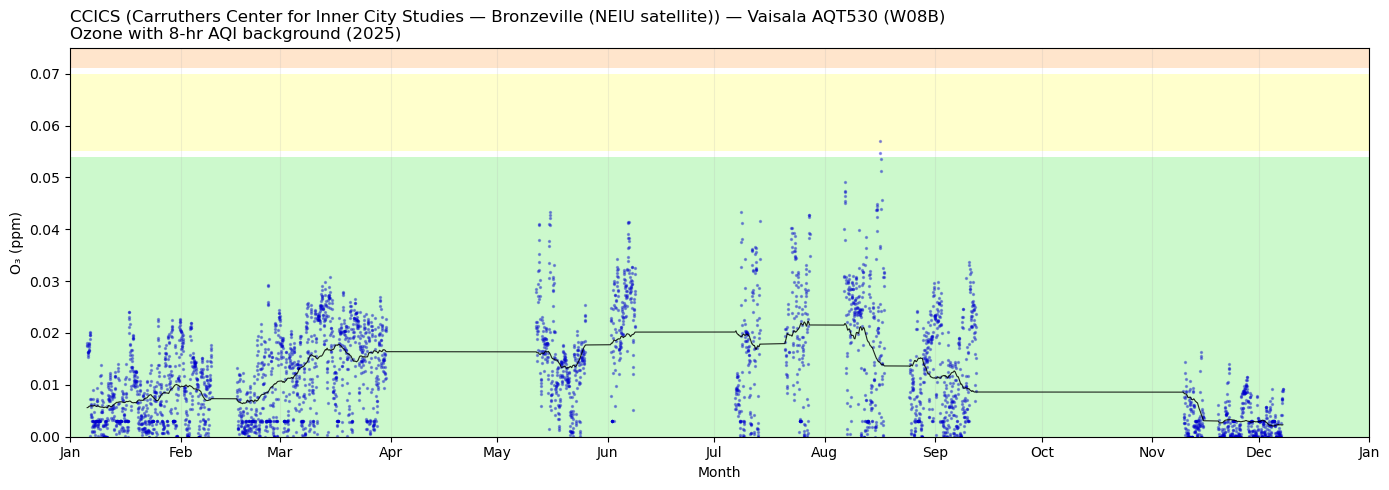

In [48]:
# Annual ozone with the 8-hour AQI background (full year, all seasons).
# AQI o3_8hr categories are defined on the 8-hour rolling mean in ppm; our
# ozone is ppb, so convert for this plot only. Uses gas_hourly (hourly series).
# Black line is a 24-hour rolling mean (diurnal cycle removed).
from aqi_colors import aqi_boxes  # (already imported via plot_utils path)

o3_ppm = gas_hourly["o3"] * (1.0 / 1000.0)          # ppb back to ppm for AQI
o3_8hr = o3_ppm.rolling(12*24, min_periods=6, center=True).mean()
band_max = max(0.075, 1.05 * o3_8hr.max())

year_start = dt.datetime(YEAR, 1, 1)
year_end = dt.datetime(YEAR + 1, 1, 1)

fig, ax = plt.subplots(figsize=(14, 5))
for box in aqi_boxes("o3_8hr", year_start, year_end, band_max):
    ax.add_patch(box)

ax.plot(gas_hourly.index, o3_ppm.to_numpy(), linestyle="none", marker="o",
        markersize=1.4, color="mediumblue", alpha=0.35)
ax.plot(o3_8hr.index, o3_8hr.to_numpy(), color="black", linewidth=0.8, alpha=0.85)

ax.set_xlim(year_start, year_end)
ax.set_ylim(0, band_max)
ax.set_ylabel("O\u2083 (ppm)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlabel("Month")
ax.grid(axis="x", alpha=0.2)
ax.set_title(
    f"{SITE} ({SITE_FULL_NAME}) \u2014 {AQT_INSTRUMENT} ({AQT_VSN})\n"
    f"Ozone with 8-hr AQI background ({YEAR})",
    loc="left",
)

fig.tight_layout()
save = FIGURE_DIR / f"{SITE.lower()}_ozone_timeseries_{YEAR}.png"
fig.savefig(save, dpi=300, bbox_inches="tight"); print("Saved", save)
plt.show()

## 1. Time-of-day calendar heatmaps

Hour-of-day vs day-of-year for hourly ozone and NO₂ (continuous colormap,
scaled to the 2nd–98th percentile). Gases are ppb; urban CROCUS ozone stays
below AQI category thresholds, so a continuous scale (not AQI) shows the
diurnal/seasonal structure.


Saved figures/resampled/ccics/ccics_ozone_heatmap_2025.png


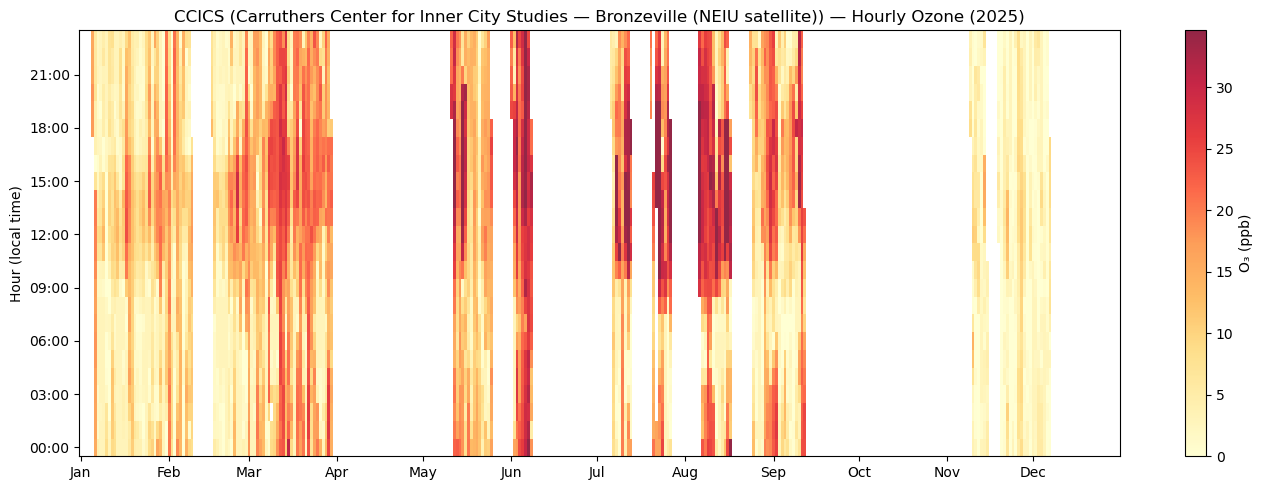

In [49]:
o3_vmin, o3_vmax = np.nanpercentile(gas_hourly["o3"].dropna(), [2, 98])
fig, ax = plt.subplots(figsize=(14, 5))
plot_hourly_heatmap(
    gas_hourly, datetime_col=None, value_col="o3",
    title=f"{SITE} ({SITE_FULL_NAME}) — Hourly Ozone ({YEAR})",
    colorbar_label="O₃ (ppb)", cmap="YlOrRd", vmin=o3_vmin, vmax=o3_vmax, ax=ax,
)
fig.tight_layout()
save = FIGURE_DIR / f"{SITE.lower()}_ozone_heatmap_{YEAR}.png"
fig.savefig(save, dpi=300, bbox_inches="tight"); print("Saved", save)
plt.show()


Saved figures/resampled/ccics/ccics_no2_heatmap_2025.png


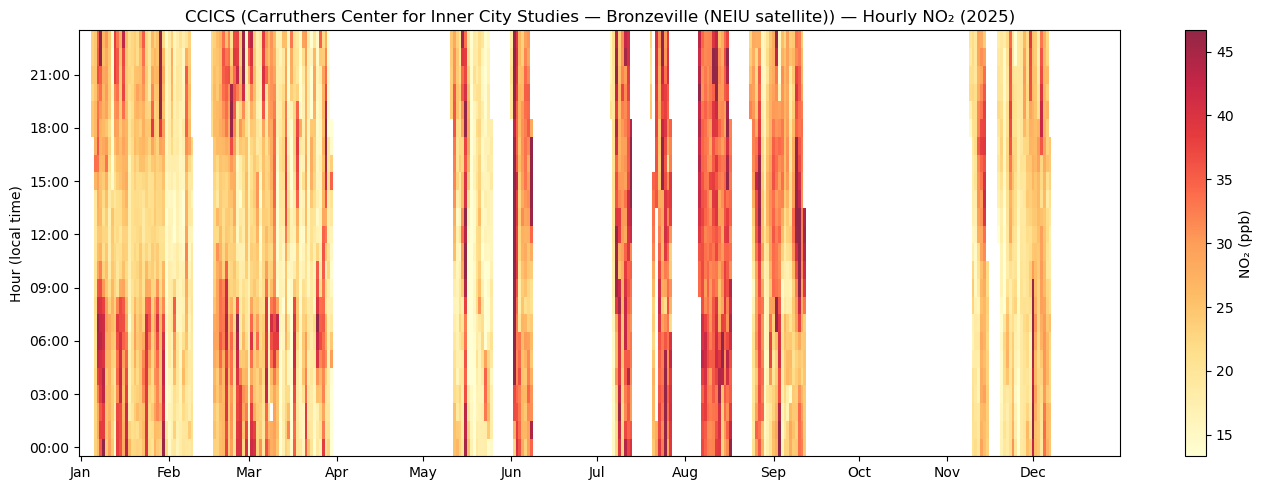

In [50]:
no2_vmin, no2_vmax = np.nanpercentile(gas_hourly["no2"].dropna(), [2, 98])
fig, ax = plt.subplots(figsize=(14, 5))
plot_hourly_heatmap(
    gas_hourly, datetime_col=None, value_col="no2",
    title=f"{SITE} ({SITE_FULL_NAME}) — Hourly NO₂ ({YEAR})",
    colorbar_label="NO₂ (ppb)", cmap="YlOrRd", vmin=no2_vmin, vmax=no2_vmax, ax=ax,
)
fig.tight_layout()
save = FIGURE_DIR / f"{SITE.lower()}_no2_heatmap_{YEAR}.png"
fig.savefig(save, dpi=300, bbox_inches="tight"); print("Saved", save)
plt.show()


In [51]:
# Diagnose the empty-paired problem.
print("AQT span:", aqt.index.min(), "->", aqt.index.max())
print("WXT span:", wxt.index.min(), "->", wxt.index.max())

_joined = aqt.join(wxt, how="inner")
print(f"\njoined (all years): {len(_joined):,} rows")
print("joined span:", _joined.index.min(), "->", _joined.index.max())
print("years present:", sorted(_joined.index.year.unique()))

for y in sorted(_joined.index.year.unique()):
    n = (_joined.index.year == y).sum()
    print(f"  {y}: {n:,} rows")

# how many survive the wdir dropna?
_pdrop = _joined.dropna(subset=["wdir"])
print(f"\nafter dropna(wdir): {len(_pdrop):,}")
print(f"of those, in {YEAR}: {(_pdrop.index.year == YEAR).sum():,}")

AQT span: 2024-09-25 09:30:00 -> 2025-12-07 17:55:00
WXT span: 2024-09-25 09:30:00 -> 2025-12-07 17:55:00

joined (all years): 65,264 rows
joined span: 2024-09-25 09:30:00 -> 2025-12-07 17:55:00
years present: [2024, 2025]
  2024: 16,042 rows
  2025: 49,222 rows

after dropna(wdir): 59,263
of those, in 2025: 46,153


## 2. Wind direction convention check

The WXT archive already stores `wind_dir` as direction-**from** (standard
meteorological u/v convention, per the file's `wind_convention` attribute), so
no sign fix is expected. We still verify on the highest-ozone afternoons.


In [52]:
# Rank high-ozone days robustly: ozone-season only, and by daily 99th
# percentile of hourly-averaged ozone (not raw 5-min max), so a single
# glitchy bin can't crown a day (e.g. the Jan 25 electrochemical spike).
_season = paired[paired.index.month.isin(OZONE_SEASON_MONTHS)]
_hourly_o3 = _season["o3"].resample("1h").mean()
daily_rank_o3 = (
    _hourly_o3.resample("1D").quantile(0.99)
    .dropna().sort_values(ascending=False)
)
top_three_dates = [d.date() for d in daily_rank_o3.head(3).index]
print("Top-3 ozone-season days (by daily 99th pct of hourly O3):", top_three_dates)

# For the event-panel titles, still report each day's peak (hourly) ozone.
daily_max_o3 = _hourly_o3.resample("1D").max()
daily_max_o3 = daily_max_o3.reindex([pd.Timestamp(d) for d in top_three_dates])

Top-3 ozone-season days (by daily 99th pct of hourly O3): [datetime.date(2025, 8, 16), datetime.date(2025, 8, 6), datetime.date(2025, 8, 15)]


## 3. High-ozone event panels

Three columns = the three highest-ozone days. Rows: ozone+NO₂, wind direction
(dot size = speed), and temperature. No radiation at CROCUS sites; instead the
bottom row overplots **WXT** temperature (solid, official) and **AQT**
temperature (dashed, QA) as a cross-instrument check. Raw 5-min dots with a
rolling-mean line. Nighttime shading uses the site's own coordinates.


Saved figures/resampled/ccics/ccics_ozone_events_2025.png


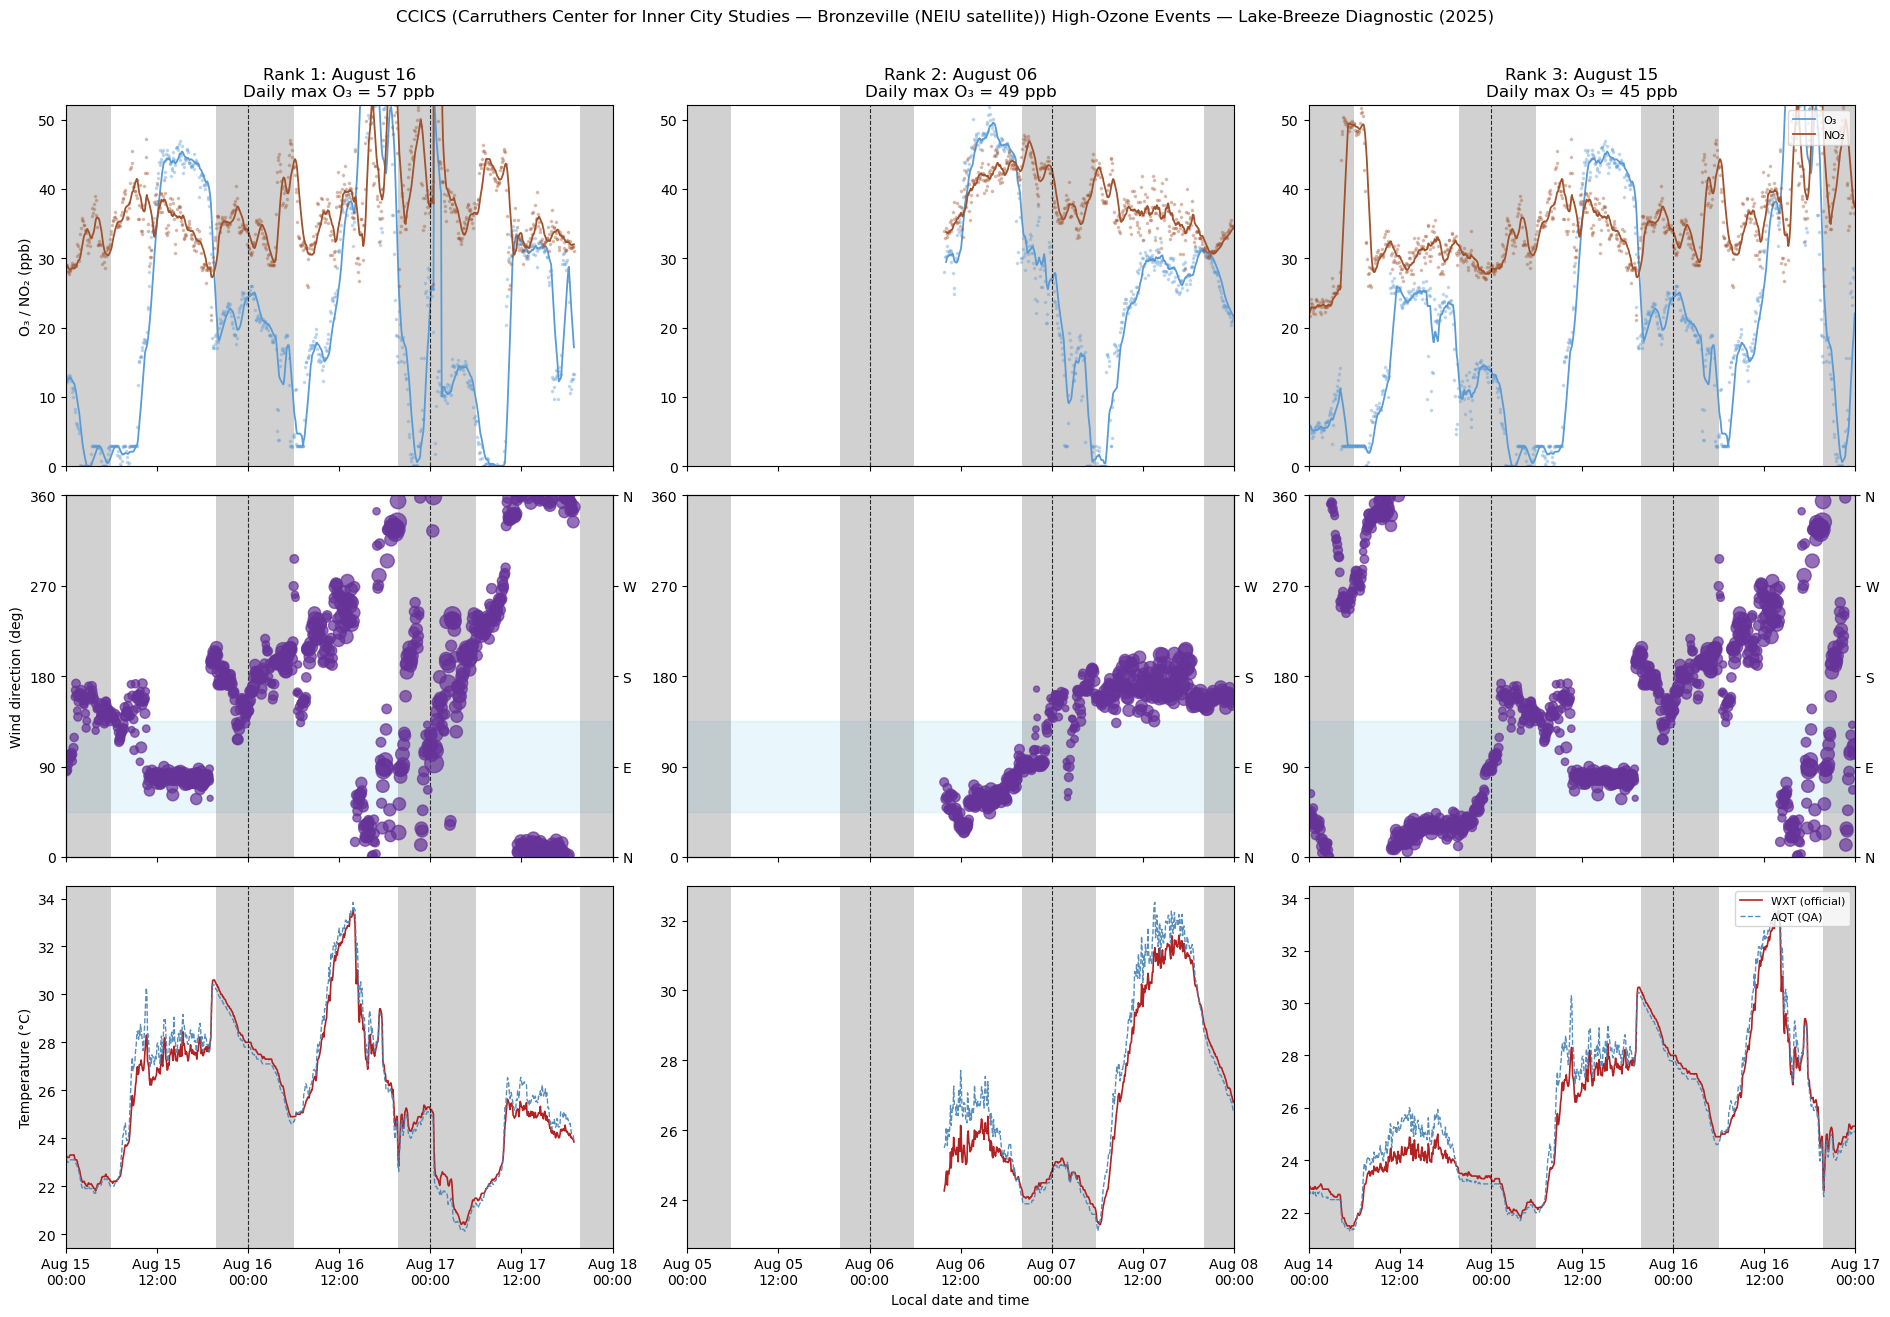

In [60]:
SIZE_FLOOR, SIZE_GAIN = 12, 9
ROLL_WINDOW = 12                     # 12 x 5 min = 1 hour
ONSHORE = (45, 135)                  # E sector; adjust per site geography


def event_window(peak_date):
    d0 = pd.Timestamp(peak_date).normalize()
    return d0 - pd.Timedelta(days=1), d0, d0 + pd.Timedelta(days=2)


def win(frame, a, b):
    return frame[(frame.index >= a) & (frame.index < b)]


# Shared ppb ceiling for both pollutants, robust to spikes (99th percentile).
pollutant_max = 1.05 * max(
    paired["o3"].quantile(0.99),
    paired["no2"].quantile(0.99),
)

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(19, 13), sharex="col")

for col, peak_date in enumerate(top_three_dates):
    w0, peak_start, w1 = event_window(peak_date)
    peak_end = peak_start + pd.Timedelta(days=1)
    block = win(paired, w0, w1)

    ax_o3, ax_wind, ax_temp = axes[0, col], axes[1, col], axes[2, col]

    # Row 1: ozone + NO2 on a single shared ppb axis (dots + rolling mean).
    ax_o3.plot(block.index, block["o3"], "o", ms=1.6,
               color=OZONE_COLOR, alpha=0.30)
    o3_line = ax_o3.plot(
        block.index, block["o3"].rolling(ROLL_WINDOW, min_periods=3).mean(),
        color=OZONE_COLOR, lw=1.3, label="O\u2083",
    )[0]
    ax_o3.plot(block.index, block["no2"], "o", ms=1.6,
               color=NO2_COLOR, alpha=0.30)
    no2_line = ax_o3.plot(
        block.index, block["no2"].rolling(ROLL_WINDOW, min_periods=3).mean(),
        color=NO2_COLOR, lw=1.3, label="NO\u2082",
    )[0]
    ax_o3.set_ylim(0, pollutant_max)
    if col == 0:
        ax_o3.set_ylabel("O\u2083 / NO\u2082 (ppb)")
    if col == 2:
        ax_o3.legend(handles=[o3_line, no2_line], loc="upper right", fontsize=8)

    # Row 2: wind direction, dot size = speed, onshore band.
    sizes = SIZE_FLOOR + SIZE_GAIN * block["wspd"].fillna(0).to_numpy()
    ax_wind.axhspan(*ONSHORE, color="skyblue", alpha=0.18, zorder=0)
    ax_wind.scatter(block.index, block["wdir"], s=sizes,
                    color="rebeccapurple", alpha=0.7, zorder=3)
    ax_wind.set_ylim(0, 360)
    ax_wind.set_yticks([0, 90, 180, 270, 360])
    if col == 0:
        ax_wind.set_ylabel("Wind direction (deg)")
    ax_wind_r = ax_wind.twinx()
    ax_wind_r.set_ylim(0, 360)
    ax_wind_r.set_yticks([0, 90, 180, 270, 360])
    ax_wind_r.set_yticklabels(["N", "E", "S", "W", "N"])

    # Row 3: WXT temp (official) vs AQT temp (QA), both degC.
    ax_temp.plot(block.index, block["temp_wxt"], color="firebrick", lw=1.2,
                 label="WXT (official)")
    ax_temp.plot(block.index, block["temp_aqt"], color="steelblue", lw=1.0,
                 linestyle="--", alpha=0.9, label="AQT (QA)")
    if col == 0:
        ax_temp.set_ylabel("Temperature (\u00b0C)")
    if col == 2:
        ax_temp.legend(loc="upper right", fontsize=8)

    # Shared per-column decoration: nighttime, day brackets, x range/format.
    for ax in (ax_o3, ax_wind, ax_temp):
        for box in nighttime_boxes(w0.to_pydatetime(), w1.to_pydatetime(),
                                   ax.get_ylim()[1], SITE_LAT, SITE_LON,
                                   CHICAGO_TIME):
            ax.add_patch(box)
        ax.axvline(peak_start, color="black", ls="--", lw=0.8, alpha=0.8)
        ax.axvline(peak_end, color="black", ls="--", lw=0.8, alpha=0.8)
        ax.set_xlim(w0, w1)

    ax_temp.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
    ax_temp.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
    ax_o3.set_title(f"Rank {col + 1}: {peak_date:%B %d}\n"
                    f"Daily max O\u2083 = {daily_max_o3.iloc[col]:.0f} ppb")

axes[2, 1].set_xlabel("Local date and time")
fig.suptitle(f"{SITE} ({SITE_FULL_NAME}) High-Ozone Events \u2014 "
             f"Lake-Breeze Diagnostic ({YEAR})", y=1.01)
fig.tight_layout()
save = FIGURE_DIR / f"{SITE.lower()}_ozone_events_{YEAR}.png"
fig.savefig(save, dpi=300, bbox_inches="tight")
print("Saved", save)
plt.show()

## 4. Wind roses

Same machinery as the AQS and NEIU notebooks (`dark = HIGH`; wind in knots so
bins match). Roses use the 5-min ozone-season frame.


In [54]:
import sys
!{sys.executable} -m pip install --quiet windrose --break-system-packages
from windrose import WindroseAxes

WIND_CMAP = plt.cm.viridis_r
OZONE_CMAP = plt.cm.YlGnBu
NO2_CMAP = plt.cm.YlOrRd

NSECTOR = 16
CALM_LIMIT_KN = 2
WIND_SPEED_BINS = [2, 4, 8, 12, 16]     # knots

# Shared concentration bins so O3 and NO2 roses use identical color breaks
# (both pollutants occupy a similar ppb range at this site).
POLLUTANT_ROSE_BINS = [0, 10, 20, 30, 45]   # ppb

OZONE_ROSE_BINS = POLLUTANT_ROSE_BINS
NO2_ROSE_BINS = POLLUTANT_ROSE_BINS

Saved figures/resampled/ccics/ccics_wind_rose_timeofday_2025.png


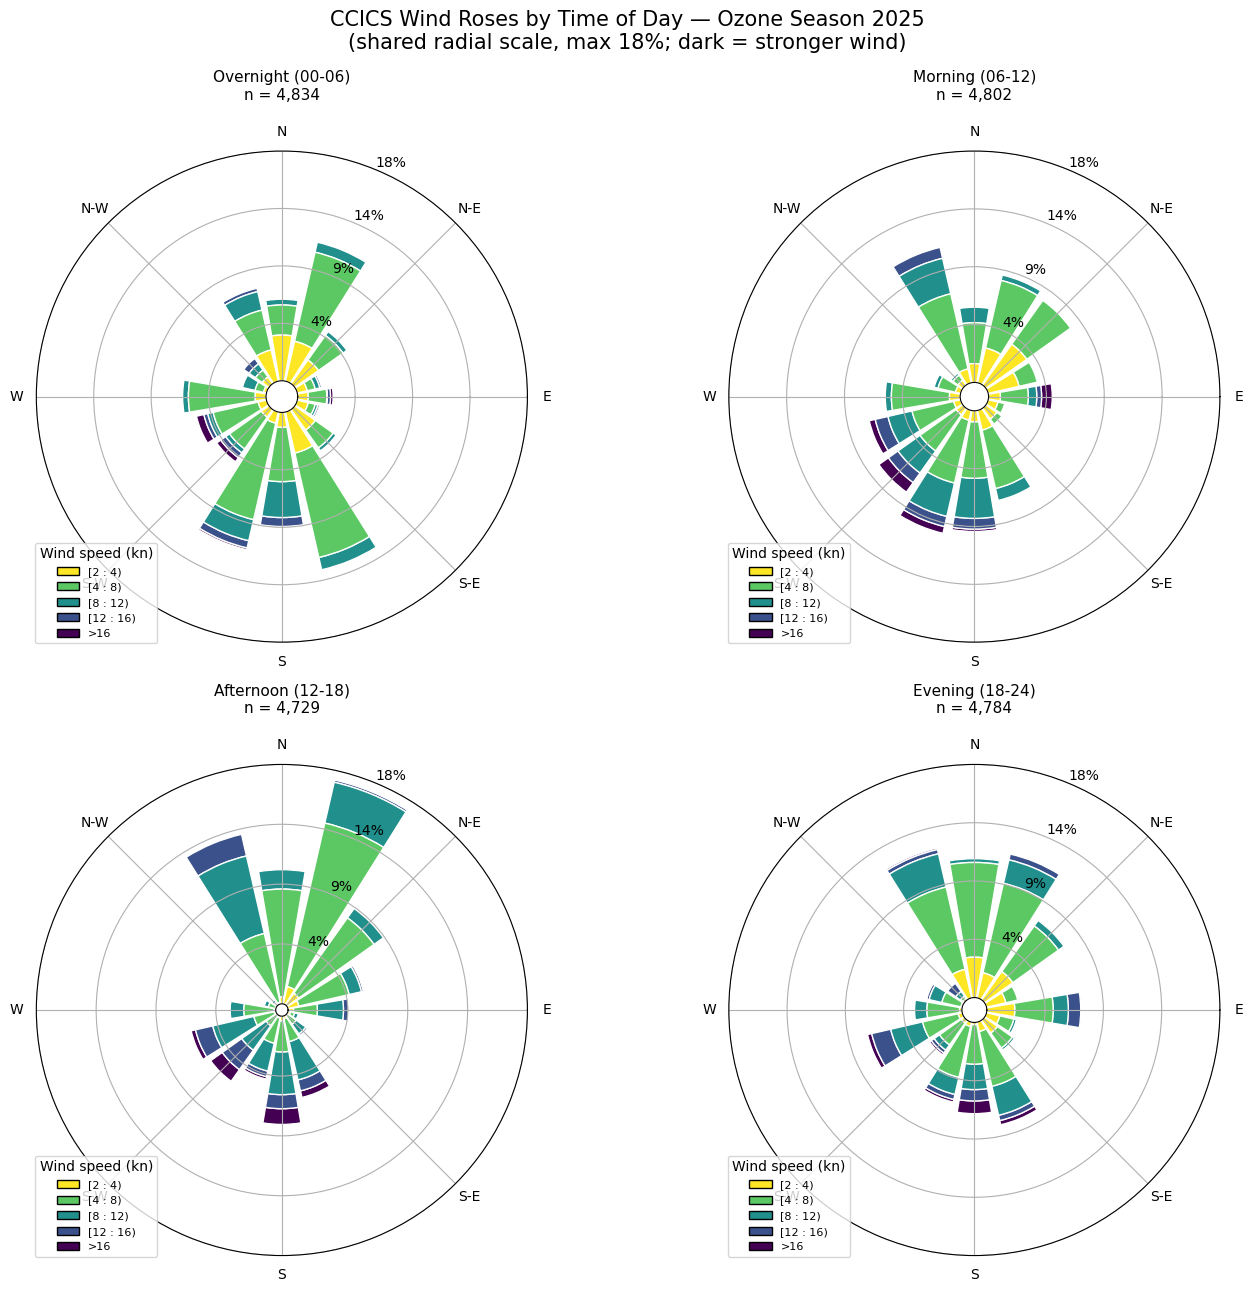

In [55]:
TIME_OF_DAY = {
    "Overnight (00-06)": range(0, 6), "Morning (06-12)": range(6, 12),
    "Afternoon (12-18)": range(12, 18), "Evening (18-24)": range(18, 24),
}
fig = plt.figure(figsize=(14, 13))
rose_axes, panel_peaks = [], []
for i, (label, hours) in enumerate(TIME_OF_DAY.items(), start=1):
    period = ozone_season[ozone_season.index.hour.isin(hours)].dropna(subset=["wspd"])
    ax = fig.add_subplot(2, 2, i, projection="windrose")
    ax.bar(period["wdir"].to_numpy(), period["wspd"].to_numpy(),
           bins=WIND_SPEED_BINS, nsector=NSECTOR, normed=True,
           opening=0.85, edgecolor="white", cmap=WIND_CMAP, calm_limit=CALM_LIMIT_KN)
    panel_peaks.append(ax._info["table"].sum(axis=0).max())
    ax.set_title(f"{label}\nn = {len(period):,}", fontsize=11, pad=18)
    ax.set_legend(title="Wind speed (kn)", loc="lower left", fontsize=8, decimal_places=0)
    rose_axes.append(ax)
tod_rmax = np.ceil(max(panel_peaks) / 2.0) * 2.0
tod_yticks = list(np.linspace(0, tod_rmax, 5))[1:]
for ax in rose_axes:
    ax.set_rmax(tod_rmax)
    ax.set_rgrids(tod_yticks, labels=[f"{t:.0f}%" for t in tod_yticks])
fig.suptitle(f"{SITE} Wind Roses by Time of Day — Ozone Season {YEAR}\n"
             f"(shared radial scale, max {tod_rmax:.0f}%; dark = stronger wind)",
             fontsize=15, y=0.99)
fig.tight_layout()
save = FIGURE_DIR / f"{SITE.lower()}_wind_rose_timeofday_{YEAR}.png"
fig.savefig(save, dpi=300, bbox_inches="tight"); print("Saved", save)
plt.show()


Saved figures/resampled/ccics/ccics_wind_ozone_no2_roses_2025.png


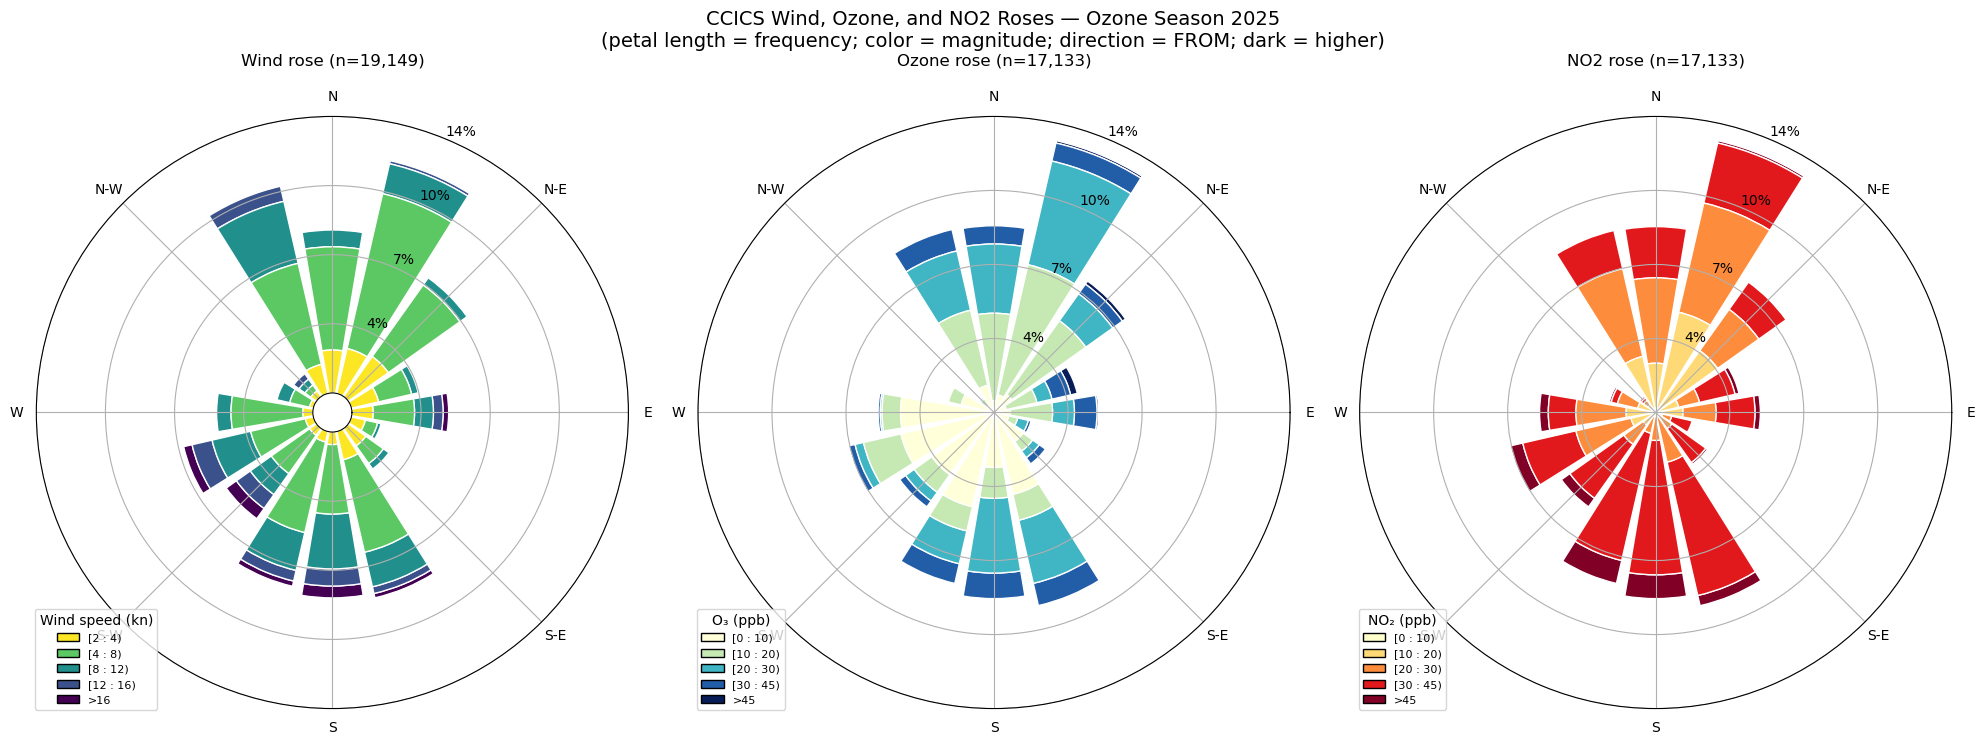

In [56]:
fig = plt.figure(figsize=(20, 7))


def _freq_rose(subplot, dir_vals, var_vals, bins, cmap, title, legend_title,
               decimals, calm=None):
    ax = fig.add_subplot(1, 3, subplot, projection="windrose")
    ax.bar(dir_vals, var_vals, bins=bins, nsector=NSECTOR, normed=True,
           opening=0.85, edgecolor="white", cmap=cmap, calm_limit=calm)
    peak = ax._info["table"].sum(axis=0).max()
    rmax = np.ceil(peak / 2.0) * 2.0
    yticks = list(np.linspace(0, rmax, 5))[1:]
    ax.set_rmax(rmax); ax.set_rgrids(yticks, labels=[f"{t:.0f}%" for t in yticks])
    ax.set_title(title, fontsize=12, pad=18)
    ax.set_legend(title=legend_title, loc="lower left", fontsize=8, decimal_places=decimals)
    return ax


wind_ok = ozone_season.dropna(subset=["wspd"])
_freq_rose(1, wind_ok["wdir"].to_numpy(), wind_ok["wspd"].to_numpy(),
           WIND_SPEED_BINS, WIND_CMAP, f"Wind rose (n={len(wind_ok):,})",
           "Wind speed (kn)", 0, calm=CALM_LIMIT_KN)
o3_ok = ozone_season.dropna(subset=["o3"])
_freq_rose(2, o3_ok["wdir"].to_numpy(), o3_ok["o3"].to_numpy(),
           OZONE_ROSE_BINS, OZONE_CMAP, f"Ozone rose (n={len(o3_ok):,})", "O₃ (ppb)", 0)
no2_ok = ozone_season.dropna(subset=["no2"])
_freq_rose(3, no2_ok["wdir"].to_numpy(), no2_ok["no2"].to_numpy(),
           NO2_ROSE_BINS, NO2_CMAP, f"NO2 rose (n={len(no2_ok):,})", "NO₂ (ppb)", 0)
fig.suptitle(f"{SITE} Wind, Ozone, and NO2 Roses — Ozone Season {YEAR}\n"
             "(petal length = frequency; color = magnitude; direction = FROM; dark = higher)",
             fontsize=14, y=1.02)
fig.tight_layout()
save = FIGURE_DIR / f"{SITE.lower()}_wind_ozone_no2_roses_{YEAR}.png"
fig.savefig(save, dpi=300, bbox_inches="tight"); print("Saved", save)
plt.show()


Saved figures/resampled/ccics/ccics_mean_concentration_roses_2025.png


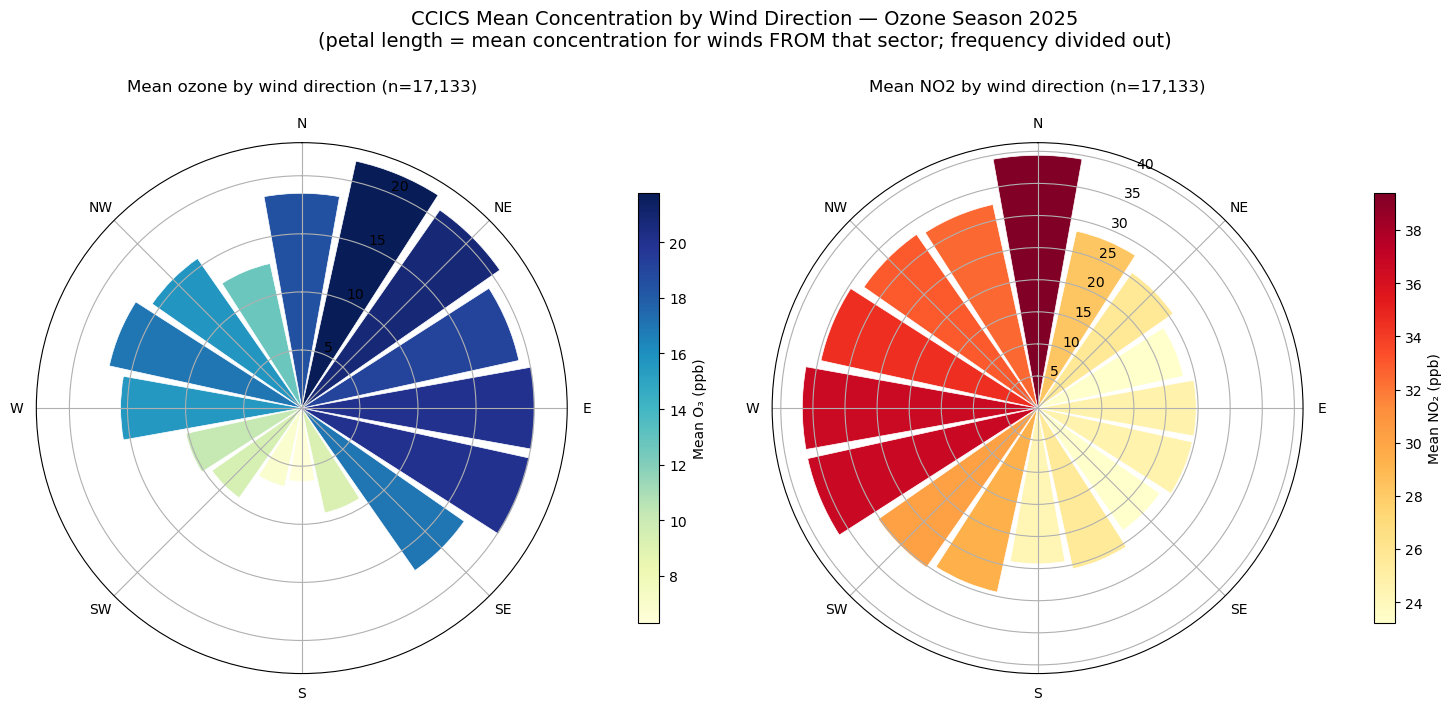

In [57]:
def mean_concentration_rose(ax, wdir, values, cmap, title, cbar_label,
                            nsector=NSECTOR, min_count=5):
    """Polar bar rose: petal length = mean value per direction sector."""
    frame = pd.DataFrame({"wdir": wdir, "val": values}).dropna()
    sector = ((frame["wdir"] % 360) // (360 / nsector)).astype(int)
    grp = frame.groupby(sector)["val"]
    means = grp.mean().reindex(range(nsector))
    counts = grp.count().reindex(range(nsector)).fillna(0)
    means = means.where(counts >= min_count)
    width = 2 * np.pi / nsector
    theta = np.deg2rad(np.arange(nsector) * (360 / nsector))
    theta_plot = (np.pi / 2) - theta
    heights = means.to_numpy()
    norm = plt.Normalize(np.nanmin(heights), np.nanmax(heights))
    ax.bar(theta_plot, np.nan_to_num(heights), width=width * 0.9,
           color=cmap(norm(heights)), edgecolor="white", linewidth=0.5)
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
    ax.set_title(title, fontsize=12, pad=18)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.7).set_label(cbar_label)


fig, axes = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={"projection": "polar"})
o3_ok = ozone_season.dropna(subset=["o3"])
mean_concentration_rose(axes[0], o3_ok["wdir"].to_numpy(), o3_ok["o3"].to_numpy(),
                        OZONE_CMAP, f"Mean ozone by wind direction (n={len(o3_ok):,})",
                        "Mean O₃ (ppb)")
no2_ok = ozone_season.dropna(subset=["no2"])
mean_concentration_rose(axes[1], no2_ok["wdir"].to_numpy(), no2_ok["no2"].to_numpy(),
                        NO2_CMAP, f"Mean NO2 by wind direction (n={len(no2_ok):,})",
                        "Mean NO₂ (ppb)")
fig.suptitle(f"{SITE} Mean Concentration by Wind Direction — Ozone Season {YEAR}\n"
             "(petal length = mean concentration for winds FROM that sector; frequency divided out)",
             fontsize=14, y=1.03)
fig.tight_layout()
save = FIGURE_DIR / f"{SITE.lower()}_mean_concentration_roses_{YEAR}.png"
fig.savefig(save, dpi=300, bbox_inches="tight"); print("Saved", save)
plt.show()


## Suggested questions

- Does high ozone at this site associate with a consistent wind sector, and
  does it match the lakeward direction for this node's location?
- Is there an afternoon onshore lobe absent in the morning (aggregate
  lake-breeze signature)? CROCUS AQT/WXT are co-located, so no wind-displacement
  confound.
- How do WXT and AQT temperature compare (event-panel bottom row)? Systematic
  offsets flag a sensor/siting issue worth noting.
- Across CROCUS sites, how does the ozone/NO₂ directional split vary with
  distance from the lake? (Re-run with a different `SITE`.)


In [58]:
print("o3 ppb-labeled range:", paired["o3"].min(), "-", paired["o3"].max())
print("o3 median:", paired["o3"].median())
print("no2 range:", paired["no2"].min(), "-", paired["no2"].max())

o3 ppb-labeled range: 0.0 - 363.2
o3 median: 9.533333333333333
no2 range: 1.0666666666666667 - 5096.2
